# RLMobTest - Treinamento DQN Melhorado

Notebook completo para treinamento do agente DQN com todas as melhorias implementadas:

-   ✅ Verificação GPU/CPU com benchmark
-   ✅ Sistema de métricas (TrainingMetrics)
-   ✅ Visualizador de métricas (MetricsVisualizer)
-   ✅ Sistema de checkpoints (ModelCheckpoint)
-   ✅ Double DQN com Target Network
-   ✅ Dueling DQN architecture
-   ✅ Prioritized Experience Replay
-   ✅ Loop de treinamento integrado


---

## 1. Setup e Verificação de Hardware


In [2]:
import sys

sys.path.insert(0, "..")

import os
import time
import logging
import random
import math
import json
from datetime import datetime
from pathlib import Path
from itertools import count
from collections import namedtuple, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

%matplotlib inline
plt.style.use("seaborn-v0_8-darkgrid")

print("Imports carregados com sucesso!")

Imports carregados com sucesso!


In [3]:
def check_device_info():
    """Verifica e exibe informações detalhadas sobre o dispositivo de processamento."""
    print("=" * 60)
    print("INFORMAÇÕES DO DISPOSITIVO DE PROCESSAMENTO")
    print("=" * 60)

    cuda_available = torch.cuda.is_available()
    print(f"\n🔧 PyTorch versão: {torch.__version__}")
    print(f"🖥️  CUDA disponível: {cuda_available}")

    if cuda_available:
        print(f"\n✅ USANDO GPU PARA PROCESSAMENTO")
        print(f"\n📊 Informações da GPU:")
        print(f"   - Versão CUDA: {torch.version.cuda}")
        print(f"   - Número de GPUs: {torch.cuda.device_count()}")

        for i in range(torch.cuda.device_count()):
            print(f"\n   GPU {i}: {torch.cuda.get_device_name(i)}")
            props = torch.cuda.get_device_properties(i)
            print(f"   - Memória total: {props.total_memory / 1024**3:.2f} GB")
            print(f"   - Multiprocessadores: {props.multi_processor_count}")
            mem_allocated = torch.cuda.memory_allocated(i) / 1024**2
            mem_reserved = torch.cuda.memory_reserved(i) / 1024**2
            print(f"   - Memória alocada: {mem_allocated:.2f} MB")
    else:
        print(f"\n⚠️  USANDO CPU PARA PROCESSAMENTO")
        print("   Para usar GPU, instale PyTorch com CUDA:")
        print("   pip install torch --index-url https://download.pytorch.org/whl/cu118")

    device = torch.device("cuda" if cuda_available else "cpu")
    print(f"\n🎯 Device padrão: {device}")
    return device


device = check_device_info()

INFORMAÇÕES DO DISPOSITIVO DE PROCESSAMENTO

🔧 PyTorch versão: 2.9.1+cu128
🖥️  CUDA disponível: True

✅ USANDO GPU PARA PROCESSAMENTO

📊 Informações da GPU:
   - Versão CUDA: 12.8
   - Número de GPUs: 1

   GPU 0: NVIDIA GeForce RTX 4060 Ti
   - Memória total: 7.62 GB
   - Multiprocessadores: 34
   - Memória alocada: 0.00 MB

🎯 Device padrão: cuda


In [4]:
def benchmark_device(device, size=1000, iterations=100):
    """Benchmark simples de multiplicação de matrizes."""
    a = torch.randn(size, size, device=device)
    b = torch.randn(size, size, device=device)

    # Warmup
    for _ in range(10):
        _ = torch.matmul(a, b)
    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()
    for _ in range(iterations):
        _ = torch.matmul(a, b)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start

    print(f"\n⏱️  Benchmark ({device}):")
    print(f"   {iterations} multiplicações de matrizes {size}x{size}")
    print(f"   Tempo total: {elapsed:.3f}s")
    print(f"   Tempo médio: {elapsed / iterations * 1000:.3f}ms")
    return elapsed


benchmark_device(device)


⏱️  Benchmark (cuda):
   100 multiplicações de matrizes 1000x1000
   Tempo total: 0.021s
   Tempo médio: 0.208ms


0.020793914794921875

---

## 2. Classes de Suporte


In [5]:
class TrainingMetrics:
    """Sistema de monitoramento e registro de métricas de treinamento."""

    def __init__(self, save_path="../output/metrics"):
        self.save_path = Path(save_path)
        self.save_path.mkdir(parents=True, exist_ok=True)

        # Métricas por episódio
        self.episode_rewards = []
        self.episode_lengths = []
        self.episode_losses = []
        self.episode_q_values = []

        # Métricas recentes (buffer circular)
        self.recent_losses = deque(maxlen=1000)
        self.recent_q_values = deque(maxlen=1000)
        self.recent_rewards = deque(maxlen=1000)
        self.epsilon_values = []

        # Contadores
        self.total_steps = 0
        self.total_episodes = 0
        self.current_episode_reward = 0
        self.current_episode_steps = 0
        self.current_episode_losses = []
        self.current_episode_q_values = []
        self.start_time = datetime.now()

    def log_step(self, reward, loss=None, q_value=None, epsilon=None):
        """Registra métricas de um step."""
        self.total_steps += 1
        self.current_episode_steps += 1
        self.current_episode_reward += reward
        self.recent_rewards.append(reward)

        if loss is not None:
            self.recent_losses.append(loss)
            self.current_episode_losses.append(loss)
        if q_value is not None:
            self.recent_q_values.append(q_value)
            self.current_episode_q_values.append(q_value)
        if epsilon is not None:
            self.epsilon_values.append(epsilon)

    def end_episode(self):
        """Finaliza um episódio e consolida métricas."""
        self.total_episodes += 1
        self.episode_rewards.append(self.current_episode_reward)
        self.episode_lengths.append(self.current_episode_steps)

        if self.current_episode_losses:
            self.episode_losses.append(np.mean(self.current_episode_losses))
        if self.current_episode_q_values:
            self.episode_q_values.append(np.mean(self.current_episode_q_values))

        # Reset
        self.current_episode_reward = 0
        self.current_episode_steps = 0
        self.current_episode_losses = []
        self.current_episode_q_values = []

    def get_summary(self):
        """Retorna resumo das métricas."""
        summary = {
            "total_episodes": self.total_episodes,
            "total_steps": self.total_steps,
            "training_time": str(datetime.now() - self.start_time),
        }
        if self.episode_rewards:
            summary["avg_reward_last_10"] = np.mean(self.episode_rewards[-10:])
            summary["avg_reward_last_100"] = (
                np.mean(self.episode_rewards[-100:])
                if len(self.episode_rewards) >= 100
                else np.mean(self.episode_rewards)
            )
            summary["max_reward"] = max(self.episode_rewards)
            summary["min_reward"] = min(self.episode_rewards)
        if self.episode_lengths:
            summary["avg_episode_length"] = np.mean(self.episode_lengths[-100:])
        if self.recent_losses:
            summary["current_loss"] = np.mean(list(self.recent_losses)[-100:])
        if self.recent_q_values:
            summary["current_q_value"] = np.mean(list(self.recent_q_values)[-100:])
        return summary

    def save_metrics(self, filename=None):
        """Salva métricas em arquivo JSON."""
        if filename is None:
            filename = f"metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        data = {
            "summary": self.get_summary(),
            "episode_rewards": self.episode_rewards,
            "episode_lengths": self.episode_lengths,
            "episode_losses": self.episode_losses,
            "episode_q_values": self.episode_q_values,
            "epsilon_values": self.epsilon_values[-1000:],
        }
        filepath = self.save_path / filename
        with open(filepath, "w") as f:
            json.dump(data, f, indent=2, default=str)
        print(f"✅ Métricas salvas em: {filepath}")
        return filepath


print("✅ TrainingMetrics definido")

✅ TrainingMetrics definido


In [6]:
class MetricsVisualizer:
    """Visualizador de métricas de treinamento."""

    @staticmethod
    def plot_training_progress(metrics, window=10):
        """Plota gráficos de progresso."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle("Progresso do Treinamento DQN", fontsize=14, fontweight="bold")

        # Recompensas
        ax1 = axes[0, 0]
        if metrics.episode_rewards:
            episodes = range(1, len(metrics.episode_rewards) + 1)
            ax1.plot(episodes, metrics.episode_rewards, alpha=0.3, label="Recompensa")
            if len(metrics.episode_rewards) >= window:
                moving_avg = (
                    pd.Series(metrics.episode_rewards).rolling(window=window).mean()
                )
                ax1.plot(
                    episodes, moving_avg, linewidth=2, label=f"Média móvel ({window})"
                )
            ax1.set_xlabel("Episódio")
            ax1.set_ylabel("Recompensa Total")
            ax1.set_title("Recompensa por Episódio")
            ax1.legend()
            ax1.grid(True, alpha=0.3)

        # Duração
        ax2 = axes[0, 1]
        if metrics.episode_lengths:
            episodes = range(1, len(metrics.episode_lengths) + 1)
            ax2.plot(
                episodes,
                metrics.episode_lengths,
                alpha=0.3,
                color="green",
                label="Steps",
            )
            if len(metrics.episode_lengths) >= window:
                moving_avg = (
                    pd.Series(metrics.episode_lengths).rolling(window=window).mean()
                )
                ax2.plot(
                    episodes,
                    moving_avg,
                    linewidth=2,
                    color="darkgreen",
                    label=f"Média móvel ({window})",
                )
            ax2.set_xlabel("Episódio")
            ax2.set_ylabel("Número de Steps")
            ax2.set_title("Duração dos Episódios")
            ax2.legend()
            ax2.grid(True, alpha=0.3)

        # Loss
        ax3 = axes[1, 0]
        if metrics.episode_losses:
            episodes = range(1, len(metrics.episode_losses) + 1)
            ax3.plot(
                episodes, metrics.episode_losses, alpha=0.3, color="red", label="Loss"
            )
            if len(metrics.episode_losses) >= window:
                moving_avg = (
                    pd.Series(metrics.episode_losses).rolling(window=window).mean()
                )
                ax3.plot(
                    episodes,
                    moving_avg,
                    linewidth=2,
                    color="darkred",
                    label=f"Média móvel ({window})",
                )
            ax3.set_xlabel("Episódio")
            ax3.set_ylabel("Loss")
            ax3.set_title("Loss Médio por Episódio")
            ax3.legend()
            ax3.grid(True, alpha=0.3)

        # Q-Values
        ax4 = axes[1, 1]
        if metrics.episode_q_values:
            episodes = range(1, len(metrics.episode_q_values) + 1)
            ax4.plot(
                episodes,
                metrics.episode_q_values,
                alpha=0.3,
                color="purple",
                label="Q-Value",
            )
            if len(metrics.episode_q_values) >= window:
                moving_avg = (
                    pd.Series(metrics.episode_q_values).rolling(window=window).mean()
                )
                ax4.plot(
                    episodes,
                    moving_avg,
                    linewidth=2,
                    color="darkviolet",
                    label=f"Média móvel ({window})",
                )
            ax4.set_xlabel("Episódio")
            ax4.set_ylabel("Q-Value Médio")
            ax4.set_title("Q-Values Médios por Episódio")
            ax4.legend()
            ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        return fig

    @staticmethod
    def plot_epsilon_decay(metrics):
        """Plota curva de decaimento do epsilon."""
        if not metrics.epsilon_values:
            print("Sem dados de epsilon")
            return
        plt.figure(figsize=(10, 4))
        plt.plot(metrics.epsilon_values, color="orange")
        plt.xlabel("Step")
        plt.ylabel("Epsilon")
        plt.title("Decaimento do Epsilon (Taxa de Exploração)")
        plt.grid(True, alpha=0.3)
        plt.axhline(
            y=0.01, color="r", linestyle="--", alpha=0.5, label="Epsilon mínimo"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def print_summary(metrics):
        """Imprime resumo formatado."""
        summary = metrics.get_summary()
        print(f"\n{'=' * 50}")
        print(
            f"📊 RESUMO - Ep: {summary.get('total_episodes', 0)} | Steps: {summary.get('total_steps', 0)}"
        )
        if "avg_reward_last_10" in summary:
            print(
                f"🎯 Reward (últimos 10): {summary['avg_reward_last_10']:.2f} | Max: {summary['max_reward']:.2f}"
            )
        if "current_loss" in summary:
            print(f"📉 Loss: {summary['current_loss']:.4f}")
        print(f"⏱️  Tempo: {summary.get('training_time', 'N/A')}")
        print(f"{'=' * 50}")


print("✅ MetricsVisualizer definido")

✅ MetricsVisualizer definido


In [7]:
class ModelCheckpoint:
    """Gerenciador de checkpoints para salvar e carregar modelos."""

    def __init__(self, save_dir="../output/checkpoints"):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def save_checkpoint(
        self, model, optimizer, metrics, episode, steps_done, filename=None
    ):
        """Salva checkpoint completo."""
        if filename is None:
            filename = (
                f"checkpoint_ep{episode}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pt"
            )

        checkpoint = {
            "episode": episode,
            "steps_done": steps_done,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": {
                "episode_rewards": metrics.episode_rewards,
                "episode_lengths": metrics.episode_lengths,
                "episode_losses": metrics.episode_losses,
                "episode_q_values": metrics.episode_q_values,
            },
            "timestamp": datetime.now().isoformat(),
        }

        filepath = self.save_dir / filename
        torch.save(checkpoint, filepath)
        print(
            f"✅ Checkpoint salvo: {filepath.name} (Ep: {episode}, Steps: {steps_done})"
        )
        return filepath

    def load_checkpoint(self, filepath, model, optimizer, metrics=None):
        """Carrega checkpoint."""
        checkpoint = torch.load(filepath, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        if metrics is not None and "metrics" in checkpoint:
            metrics.episode_rewards = checkpoint["metrics"].get("episode_rewards", [])
            metrics.episode_lengths = checkpoint["metrics"].get("episode_lengths", [])
            metrics.episode_losses = checkpoint["metrics"].get("episode_losses", [])
            metrics.episode_q_values = checkpoint["metrics"].get("episode_q_values", [])
            metrics.total_episodes = len(metrics.episode_rewards)

        print(f"✅ Checkpoint carregado: {filepath}")
        return {
            "episode": checkpoint["episode"],
            "steps_done": checkpoint["steps_done"],
        }

    def list_checkpoints(self):
        """Lista checkpoints disponíveis."""
        checkpoints = sorted(
            self.save_dir.glob("*.pt"), key=lambda x: x.stat().st_mtime, reverse=True
        )
        print(f"\n📁 Checkpoints em {self.save_dir}:")
        for cp in checkpoints[:10]:
            size = cp.stat().st_size / 1024
            print(f"   {cp.name} ({size:.1f} KB)")
        return checkpoints


print("✅ ModelCheckpoint definido")

✅ ModelCheckpoint definido


In [8]:
class PrioritizedReplayMemory:
    """Experience Replay com priorização baseada em TD-error."""

    def __init__(self, capacity, alpha=0.6, beta_start=0.4, beta_frames=100000):
        self.capacity = capacity
        self.alpha = alpha  # Priorização (0 = uniforme, 1 = total)
        self.beta_start = beta_start
        self.beta_frames = beta_frames
        self.frame = 1
        self.buffer = []
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.position = 0

    def push(self, state, action, next_state, reward):
        """Adiciona transição com prioridade máxima."""
        max_priority = self.priorities.max() if self.buffer else 1.0

        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, next_state, reward))
        else:
            self.buffer[self.position] = (state, action, next_state, reward)

        self.priorities[self.position] = max_priority
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        """Amostra batch com probabilidade proporcional à prioridade."""
        if len(self.buffer) == 0:
            return [], [], None

        # Calcular probabilidades
        priorities = self.priorities[: len(self.buffer)]
        probs = priorities**self.alpha
        probs /= probs.sum()

        # Beta para importance sampling (aumenta de beta_start até 1.0)
        beta = min(
            1.0,
            self.beta_start + self.frame * (1.0 - self.beta_start) / self.beta_frames,
        )
        self.frame += 1

        # Amostrar índices
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[i] for i in indices]

        # Calcular pesos para correção de bias
        weights = (len(self.buffer) * probs[indices]) ** (-beta)
        weights /= weights.max()
        weights = torch.tensor(weights, dtype=torch.float32, device=device)

        return samples, indices, weights

    def update_priorities(self, indices, td_errors):
        """Atualiza prioridades baseado nos TD-errors."""
        for idx, td_error in zip(indices, td_errors):
            self.priorities[idx] = abs(td_error) + 1e-6

    def __len__(self):
        return len(self.buffer)


print("✅ PrioritizedReplayMemory definido")

✅ PrioritizedReplayMemory definido


---

## 3. Modelos DQN


In [9]:
class DQN(nn.Module):
    """DQN original do projeto (para comparação)."""

    def __init__(self, num_actions=30):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm2d(32)
        self.head = nn.Linear(448, num_actions)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        return self.head(x)


print("✅ DQN original definido")

✅ DQN original definido


In [10]:
class DuelingDQN(nn.Module):
    """Dueling DQN - separa Value e Advantage streams."""

    def __init__(self, num_actions=30):
        super(DuelingDQN, self).__init__()

        # Feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )

        # Calcular feature size dinamicamente
        self._feature_size = None
        self.num_actions = num_actions

        # Value stream
        self.value_stream = None
        # Advantage stream
        self.advantage_stream = None

    def _initialize_fc(self, feature_size):
        """Inicializa camadas FC após conhecer o tamanho."""
        self.value_stream = nn.Sequential(
            nn.Linear(feature_size, 512), nn.ReLU(), nn.Linear(512, 1)
        ).to(device)

        self.advantage_stream = nn.Sequential(
            nn.Linear(feature_size, 512), nn.ReLU(), nn.Linear(512, self.num_actions)
        ).to(device)

    def forward(self, x):
        features = self.features(x)
        features = features.view(features.size(0), -1)

        # Inicializar FC layers na primeira passagem
        if self.value_stream is None:
            self._feature_size = features.size(1)
            self._initialize_fc(self._feature_size)

        # Dueling: Q(s,a) = V(s) + (A(s,a) - mean(A(s,:)))
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)

        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))
        return q_values


print("✅ DuelingDQN definido")

✅ DuelingDQN definido


In [11]:
class DQNAgent:
    """Agente DQN completo com Double DQN, Target Network e PER."""

    def __init__(self, num_actions=30, use_dueling=True, use_per=True):
        self.device = device
        self.num_actions = num_actions
        self.use_per = use_per

        # Redes: policy e target
        ModelClass = DuelingDQN if use_dueling else DQN
        self.policy_net = ModelClass(num_actions).to(device)
        self.target_net = ModelClass(num_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Otimizador
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-4)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=10000, gamma=0.9
        )

        # Memory
        if use_per:
            self.memory = PrioritizedReplayMemory(50000)
        else:
            self.memory = ReplayMemory(50000)

        # Hiperparâmetros
        self.gamma = 0.99
        self.eps_start = 1.0
        self.eps_end = 0.01
        self.eps_decay = 10000
        self.batch_size = 128
        self.target_update = 1000

        self.steps_done = 0

    def get_epsilon(self):
        """Calcula epsilon atual."""
        return self.eps_end + (self.eps_start - self.eps_end) * math.exp(
            -1.0 * self.steps_done / self.eps_decay
        )

    def select_action(self, state, available_actions):
        """Seleciona ação usando epsilon-greedy."""
        epsilon = self.get_epsilon()
        self.steps_done += 1

        if random.random() > epsilon:
            with torch.no_grad():
                state = state.to(self.device)
                q_values = self.policy_net(state)
                q_values = q_values[0, : len(available_actions)]
                return q_values.argmax().item(), epsilon, q_values.max().item()
        else:
            return random.randrange(len(available_actions)), epsilon, 0.0

    def optimize(self):
        """Otimiza o modelo usando Double DQN."""
        if len(self.memory) < self.batch_size:
            return None

        # Amostrar batch
        if self.use_per:
            samples, indices, weights = self.memory.sample(self.batch_size)
        else:
            samples = self.memory.sample(self.batch_size)
            indices = None
            weights = torch.ones(self.batch_size, device=self.device)

        if not samples:
            return None

        # Separar batch
        batch = list(zip(*samples))
        state_batch = torch.cat([s for s in batch[0] if s is not None]).to(self.device)
        action_batch = torch.tensor(batch[1], device=self.device).unsqueeze(1)
        reward_batch = torch.tensor(batch[3], device=self.device, dtype=torch.float)

        # Máscara para estados não-terminais
        non_final_mask = torch.tensor(
            [s is not None for s in batch[2]], device=self.device, dtype=torch.bool
        )
        non_final_next_states = (
            torch.cat([s for s in batch[2] if s is not None]).to(self.device)
            if any(non_final_mask)
            else None
        )

        # Q(s, a) da policy network
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        # Double DQN: selecionar com policy, avaliar com target
        next_state_values = torch.zeros(self.batch_size, device=self.device)
        if non_final_next_states is not None:
            with torch.no_grad():
                next_actions = (
                    self.policy_net(non_final_next_states).argmax(1).unsqueeze(1)
                )
                next_state_values[non_final_mask] = (
                    self.target_net(non_final_next_states)
                    .gather(1, next_actions)
                    .squeeze()
                )

        # Target
        expected_state_action_values = reward_batch + (self.gamma * next_state_values)

        # TD-errors para PER
        td_errors = (
            (state_action_values.squeeze() - expected_state_action_values)
            .detach()
            .cpu()
            .numpy()
        )

        # Weighted loss para PER
        loss = (
            weights
            * F.smooth_l1_loss(
                state_action_values.squeeze(),
                expected_state_action_values,
                reduction="none",
            )
        ).mean()

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)
        self.optimizer.step()

        # Atualizar prioridades
        if self.use_per and indices is not None:
            self.memory.update_priorities(indices, td_errors)

        # Atualizar target network
        if self.steps_done % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()


# ReplayMemory simples para modo sem PER
class ReplayMemory:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state, action, next_state, reward):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, next_state, reward)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


print("✅ DQNAgent definido")

✅ DQNAgent definido


---

## 4. Configuração


In [12]:
# Carregar configurações do projeto
from utils.constants import TEST_CASES_PATH, TRANSCRIPTIONS_PATH, CONFIG_PATH, LOGS_PATH
from utils.config_reader import ConfRead

# Ler settings
settings_reader = ConfRead(str(CONFIG_PATH / "settings.txt"))
lines = settings_reader.read_setting()

config = {
    "apk": lines[0],
    "app_package": lines[1],
    "width": lines[2],
    "height": lines[3],
    "coverage_enabled": lines[4],
    "requirements_enabled": lines[5],
    "max_time": int(lines[6]),
    "checkpoint_interval": 10,  # Salvar a cada N episódios
}

print("📋 Configurações carregadas:")
for k, v in config.items():
    print(f"   {k}: {v}")

📋 Configurações carregadas:
   apk: budgetwatch.apk
   app_package: protect.budgetwatch
   width: 2560
   height: 1440
   coverage_enabled: no
   requirements_enabled: no
   max_time: 3600
   checkpoint_interval: 10


In [13]:
# Hiperparâmetros do treinamento
HYPERPARAMS = {
    "gamma": 0.99,  # Fator de desconto
    "eps_start": 1.0,  # Epsilon inicial
    "eps_end": 0.01,  # Epsilon final
    "eps_decay": 10000,  # Decaimento do epsilon
    "batch_size": 128,  # Tamanho do batch
    "memory_size": 50000,  # Tamanho da memória
    "target_update": 1000,  # Frequência de atualização do target
    "lr": 1e-4,  # Learning rate
    "per_alpha": 0.6,  # PER: expoente de priorização
    "per_beta_start": 0.4,  # PER: beta inicial
    "use_dueling": True,  # Usar Dueling DQN
    "use_per": True,  # Usar Prioritized Experience Replay
}

print("\n⚙️  Hiperparâmetros:")
for k, v in HYPERPARAMS.items():
    print(f"   {k}: {v}")


⚙️  Hiperparâmetros:
   gamma: 0.99
   eps_start: 1.0
   eps_end: 0.01
   eps_decay: 10000
   batch_size: 128
   memory_size: 50000
   target_update: 1000
   lr: 0.0001
   per_alpha: 0.6
   per_beta_start: 0.4
   use_dueling: True
   use_per: True


---

## 5. Loop de Treinamento


In [14]:
def calculate_reward(
    action,
    previous_action,
    activity,
    previous_activity,
    activities,
    crash,
    req_enabled,
    env,
):
    """Calcula a recompensa baseada na transição."""
    reward = 0

    # Penalidade por repetir ação
    if action == previous_action:
        reward = -2
    else:
        reward = 1

    # Mudança de activity
    if activity != previous_activity:
        if activity not in ["home", "outapp"]:
            reward += 5  # Bônus por nova tela
        else:
            reward -= 5  # Penalidade por sair do app

    # Nova activity descoberta
    if activity not in activities:
        reward += 10

    # Crash
    if crash:
        reward = -5

    return reward

In [15]:
def train_agent(env, agent, metrics, checkpoint_mgr, config, hyperparams):
    """
    Loop de treinamento principal.

    Args:
        env: AndroidEnv
        agent: DQNAgent
        metrics: TrainingMetrics
        checkpoint_mgr: ModelCheckpoint
        config: Configurações do app
        hyperparams: Hiperparâmetros de treinamento
    """
    max_time = config["max_time"]
    checkpoint_interval = config["checkpoint_interval"]
    req_enabled = config["requirements_enabled"] == "yes"

    start_time = time.time()
    episode = 0

    print(f"\n🚀 Iniciando treinamento (max_time: {max_time}s)")
    print(f"   Dueling DQN: {hyperparams['use_dueling']}")
    print(f"   Prioritized Replay: {hyperparams['use_per']}")
    print("=" * 60)

    while (time.time() - start_time) < max_time:
        episode += 1

        # Reset environment
        state, actions = env.reset()
        activities = ["home"]
        previous_activity = "home"
        previous_action_idx = 0

        if req_enabled:
            env.get_requirements()

        for step in count():
            if len(actions) == 0:
                print(f"   Ep {episode}: Sem ações disponíveis no step {step}")
                break

            # Processar estado (landscape mode)
            if state.shape[3] > state.shape[2]:
                state = state.permute(0, 1, 3, 2)

            # Selecionar ação
            action_idx, epsilon, q_value = agent.select_action(state, actions)
            action = actions[action_idx]

            # Executar ação
            next_state, next_actions, crash, activity = env.step(action)

            # Processar next_state
            if next_state is not None and next_state.shape[3] > next_state.shape[2]:
                next_state = next_state.permute(0, 1, 3, 2)

            # Calcular recompensa
            reward = calculate_reward(
                action_idx,
                previous_action_idx,
                activity,
                previous_activity,
                activities,
                crash,
                req_enabled,
                env,
            )

            # Atualizar activities
            if activity not in activities:
                activities.append(activity)

            # Armazenar transição
            next_state_store = next_state if not crash else None
            agent.memory.push(state, action_idx, next_state_store, reward)

            # Otimizar modelo
            loss = agent.optimize()

            # Registrar métricas
            metrics.log_step(reward, loss, q_value, epsilon)

            # Atualizar estado
            state = next_state
            actions = next_actions
            previous_activity = activity
            previous_action_idx = action_idx

            if crash:
                print(f"   Ep {episode}: Crash detectado no step {step}")
                break

            # Verificar tempo
            if (time.time() - start_time) > max_time:
                break

        # Finalizar episódio
        metrics.end_episode()

        # Checkpoint periódico
        if episode % checkpoint_interval == 0:
            checkpoint_mgr.save_checkpoint(
                agent.policy_net, agent.optimizer, metrics, episode, agent.steps_done
            )

        # Mostrar progresso
        if episode % 5 == 0:
            MetricsVisualizer.print_summary(metrics)

    print("\n" + "=" * 60)
    print("🏁 Treinamento finalizado!")
    MetricsVisualizer.print_summary(metrics)

    return metrics

In [16]:
# Inicializar componentes
print("Inicializando componentes...")

# Agente
agent = DQNAgent(
    num_actions=30,
    use_dueling=HYPERPARAMS["use_dueling"],
    use_per=HYPERPARAMS["use_per"],
)

# Aplicar hiperparâmetros
agent.gamma = HYPERPARAMS["gamma"]
agent.eps_start = HYPERPARAMS["eps_start"]
agent.eps_end = HYPERPARAMS["eps_end"]
agent.eps_decay = HYPERPARAMS["eps_decay"]
agent.batch_size = HYPERPARAMS["batch_size"]
agent.target_update = HYPERPARAMS["target_update"]

# Métricas e checkpoints
metrics = TrainingMetrics()
checkpoint_mgr = ModelCheckpoint()

print(f"✅ Agente inicializado")
print(
    f"   Policy Net params: {sum(p.numel() for p in agent.policy_net.parameters()):,}"
)
print(f"   Memory: {type(agent.memory).__name__}")

Inicializando componentes...
✅ Agente inicializado
   Policy Net params: 75,936
   Memory: PrioritizedReplayMemory


In [17]:
# EXECUTAR TREINAMENTO
# Descomente as linhas abaixo para treinar com o ambiente Android real

from environment import AndroidEnv
env = AndroidEnv(config['apk'], config['app_package'], coverage_enabled=config['coverage_enabled'])
env.install_app()

metrics = train_agent(env, agent, metrics, checkpoint_mgr, config, HYPERPARAMS)

print("⚠️  Para executar o treinamento real, descomente as linhas acima.")
print("   Requer dispositivo Android conectado via ADB.")

/bin/sh: 1: ng: not found
/bin/sh: 1: ng: not found
adb: failed to stat budgetwatch.apk: No such file or directory



🚀 Iniciando treinamento (max_time: 3600s)
   Dueling DQN: True
   Prioritized Replay: True


args: [-p, protect.budgetwatch, 1]
 arg: "-p"
 arg: "protect.budgetwatch"
 arg: "1"
data="protect.budgetwatch"
args: [-p, protect.budgetwatch, 1]
 arg: "-p"
 arg: "protect.budgetwatch"
 arg: "1"
data="protect.budgetwatch"


Click: android.widget.LinearLayout    bounds:[0,230][1080,408]


args: [-p, protect.budgetwatch, 1]
 arg: "-p"
 arg: "protect.budgetwatch"
 arg: "1"
data="protect.budgetwatch"


...

args: [-p, protect.budgetwatch, 1]
 arg: "-p"
 arg: "protect.budgetwatch"
 arg: "1"
data="protect.budgetwatch"


Click: android.widget.TextView android:id/date_picker_header_date  Wed, Feb 4 bounds:[140,486][592,589]


args: [-p, protect.budgetwatch, 1]
 arg: "-p"
 arg: "protect.budgetwatch"
 arg: "1"
data="protect.budgetwatch"


Click: android.view.View  10 February 2026 10 bounds:[350,979][460,1079]


KeyboardInterrupt: 

---

## 6. Simulação de Treinamento (Demo)


In [ ]:
# Simulação para demonstração (sem ambiente Android)
print("🎮 Simulando 50 episódios de treinamento para demonstração...\n")

demo_metrics = TrainingMetrics()

for episode in range(50):
    episode_length = random.randint(20, 100)

    for step in range(episode_length):
        # Simular métricas realistas
        reward = random.uniform(-5, 10) + (episode * 0.15)  # Melhora gradual
        loss = max(0.05, 2.0 - episode * 0.035 + random.uniform(-0.1, 0.1))
        q_value = 0.5 + episode * 0.08 + random.uniform(-0.3, 0.3)
        epsilon = 0.01 + (1.0 - 0.01) * math.exp(-demo_metrics.total_steps / 1000)

        demo_metrics.log_step(reward, loss, q_value, epsilon)

    demo_metrics.end_episode()

    if (episode + 1) % 10 == 0:
        print(f"Episódio {episode + 1}/50 completo")

print("\n✅ Simulação concluída!")

🎮 Simulando 50 episódios de treinamento para demonstração...

Episódio 10/50 completo
Episódio 20/50 completo
Episódio 30/50 completo
Episódio 40/50 completo
Episódio 50/50 completo

✅ Simulação concluída!



📊 RESUMO - Ep: 50 | Steps: 3029
🎯 Reward (últimos 10): 592.01 | Max: 841.82
📉 Loss: 0.2992
⏱️  Tempo: 0:00:08.883862


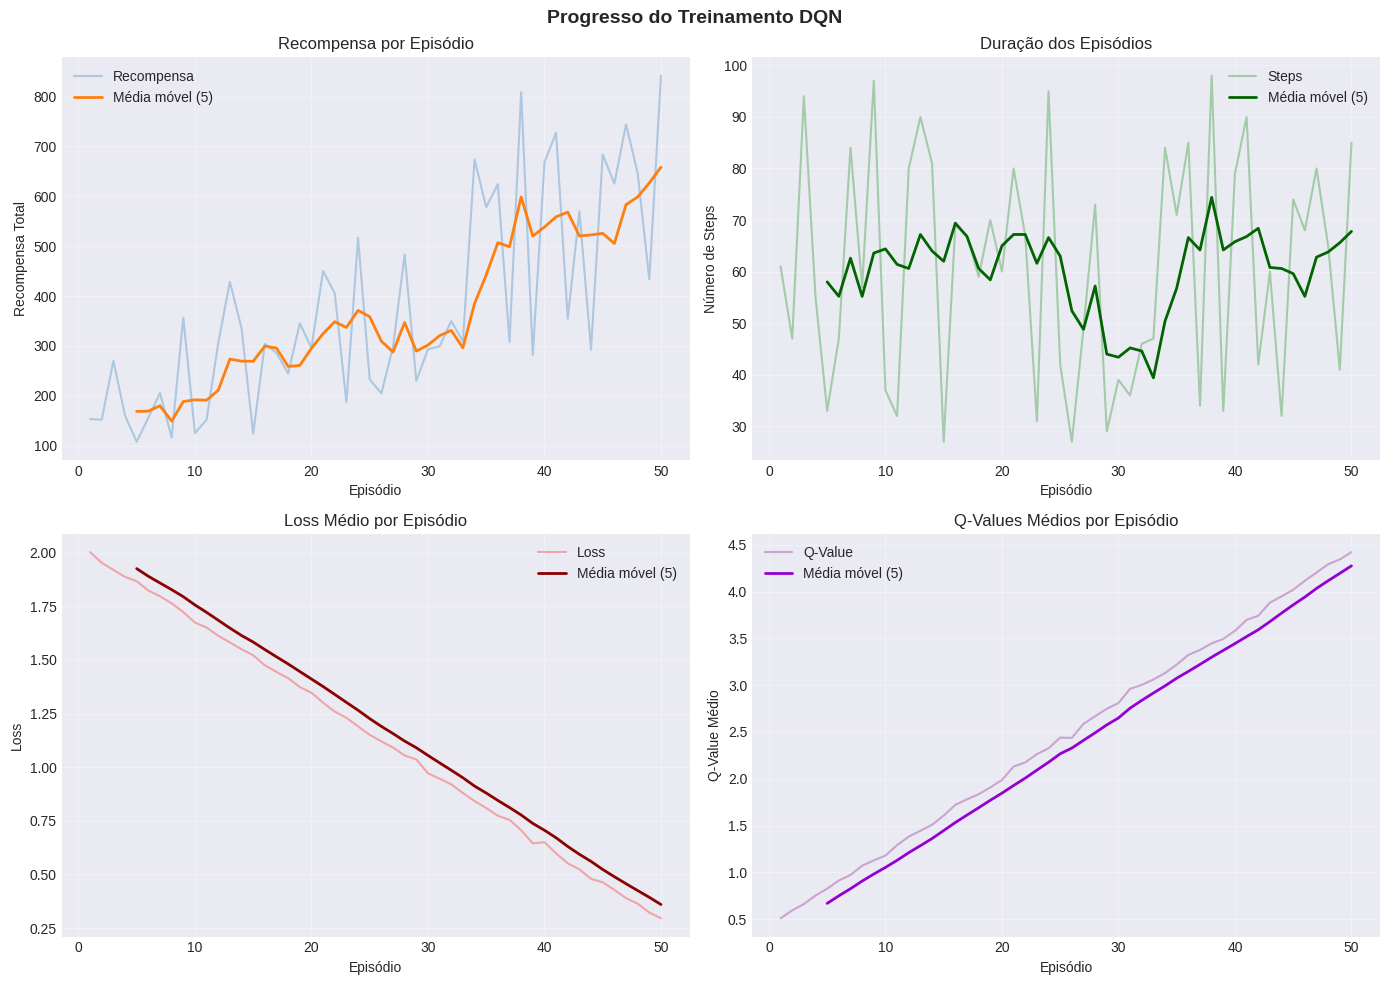

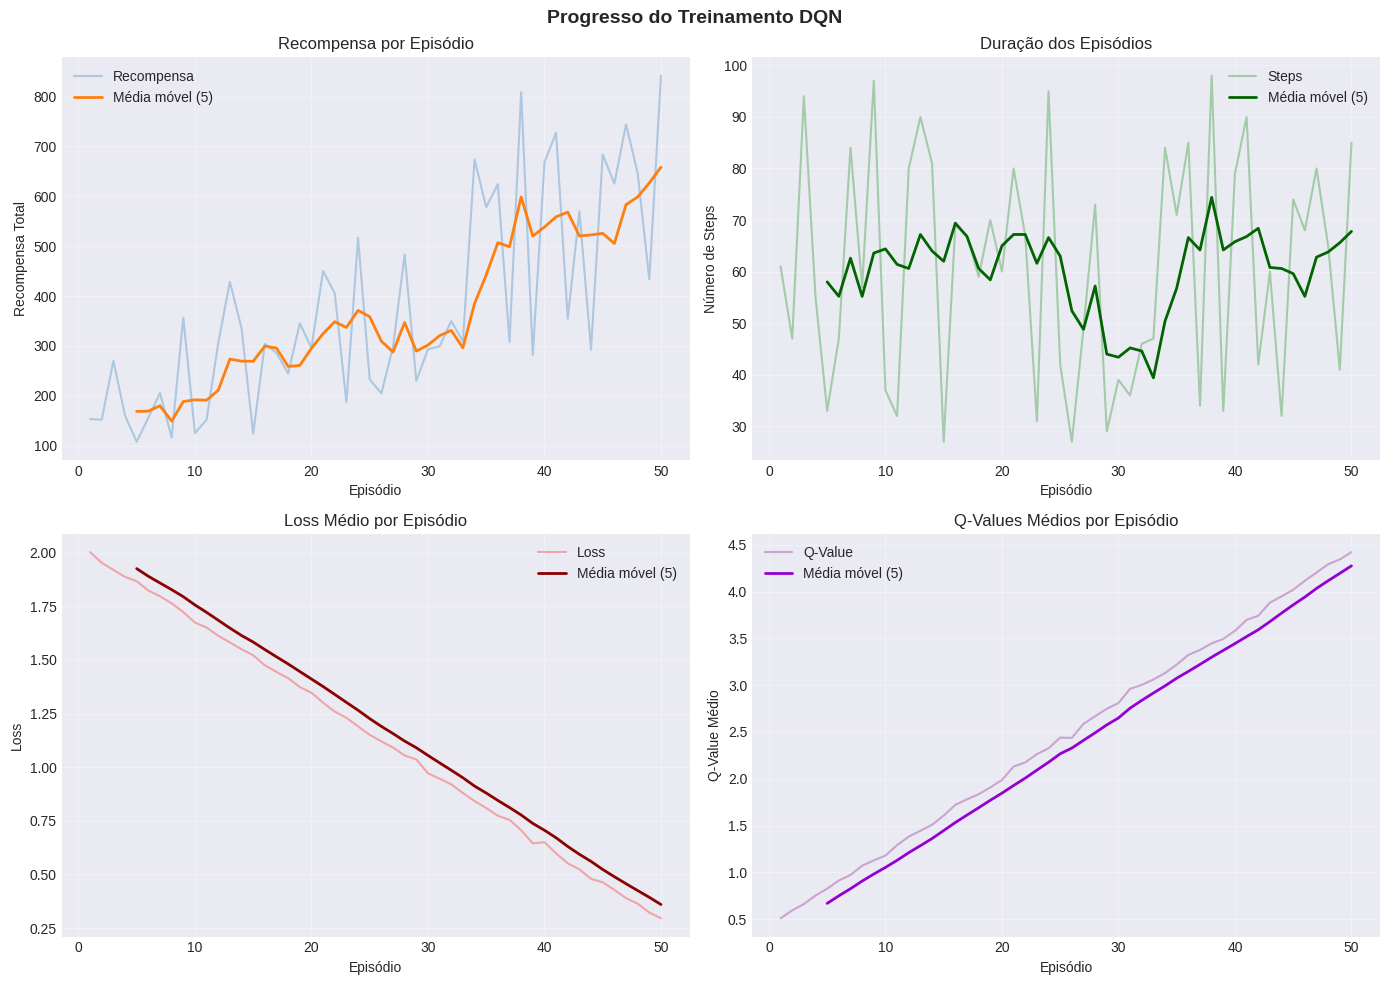

In [ ]:
# Visualizar resultados da simulação
MetricsVisualizer.print_summary(demo_metrics)
MetricsVisualizer.plot_training_progress(demo_metrics, window=5)

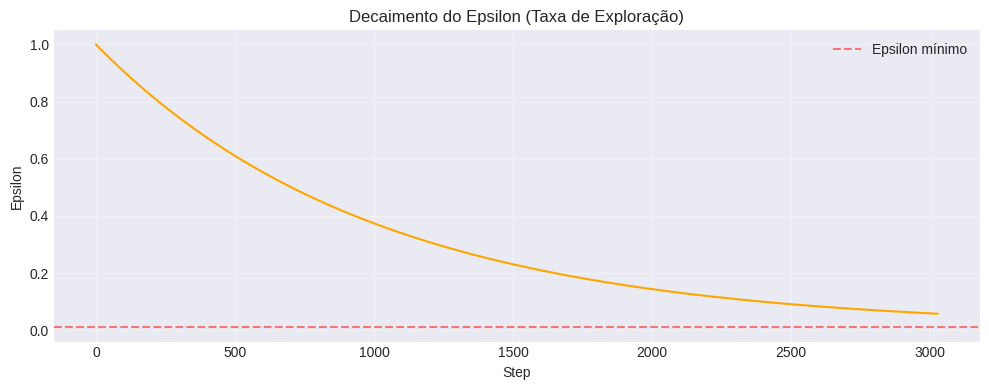

In [ ]:
# Epsilon decay
MetricsVisualizer.plot_epsilon_decay(demo_metrics)

In [ ]:
# Salvar métricas e checkpoint
demo_metrics.save_metrics("demo_training_metrics.json")

checkpoint_mgr.save_checkpoint(
    agent.policy_net,
    agent.optimizer,
    demo_metrics,
    episode=50,
    steps_done=demo_metrics.total_steps,
)

✅ Métricas salvas em: ../output/metrics/demo_training_metrics.json
✅ Checkpoint salvo: checkpoint_ep50_20251130_231810.pt (Ep: 50, Steps: 3029)


PosixPath('../output/checkpoints/checkpoint_ep50_20251130_231810.pt')

In [ ]:
# Listar checkpoints
checkpoint_mgr.list_checkpoints()


📁 Checkpoints em ../output/checkpoints:
   checkpoint_ep50_20251130_231810.pt (306.2 KB)
   checkpoint_ep50_20251130_230939.pt (224.8 KB)
   checkpoint_ep50_20251130_223631.pt (224.8 KB)


[PosixPath('../output/checkpoints/checkpoint_ep50_20251130_231810.pt'),
 PosixPath('../output/checkpoints/checkpoint_ep50_20251130_230939.pt'),
 PosixPath('../output/checkpoints/checkpoint_ep50_20251130_223631.pt')]

---

## 7. Comparação de Arquiteturas


In [23]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Criar modelos para comparação
original_dqn = DQN(30).to(device)
dueling_dqn = DuelingDQN(30).to(device)

# Forward pass para inicializar Dueling
dummy_input = torch.randn(1, 3, 84, 84).to(device)
_ = dueling_dqn(dummy_input)

print("\n📊 Comparação de Arquiteturas:")
print("=" * 50)
print(f"\nDQN Original:")
print(f"  Parâmetros: {count_parameters(original_dqn):,}")
print(f"\nDueling DQN:")
print(f"  Parâmetros: {count_parameters(dueling_dqn):,}")


📊 Comparação de Arquiteturas:

DQN Original:
  Parâmetros: 53,310

Dueling DQN:
  Parâmetros: 3,304,127


---

## Resumo

### Implementações neste notebook:

-   ✅ Verificação GPU/CPU com benchmark
-   ✅ TrainingMetrics - monitoramento de métricas
-   ✅ MetricsVisualizer - visualização de gráficos
-   ✅ ModelCheckpoint - persistência de modelos
-   ✅ PrioritizedReplayMemory - replay com prioridade
-   ✅ DQN original e DuelingDQN
-   ✅ DQNAgent com Double DQN + Target Network
-   ✅ Loop de treinamento integrado

### Para executar treinamento real:

1. Conectar dispositivo Android via USB
2. Habilitar depuração USB
3. Verificar conexão: `adb devices`
4. Configurar `config/settings.txt` com o APK correto
5. Descomentar células na Seção 5
